# Networkx

* Пакет для Python для манипулирования графиками и их анализа
* Содержит множество стандатных алгоритмов для графов

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## Создание графов

Networkx поддерживает неориентированные/ориентированные графы/мультиграфы (мультиграфы позволяют одной паре узлов иметь несколько ребер):
*  Неориентированный граф: `nx.Graph`
*  Ориентированный граф: `nx.DiGraph`
*  Неориентированный мультиграф: `nx.MultiGraph`
*  Ориентированный мультиграф: `nx.MultiDiGraph`

In [3]:
# Неориентированный граф
G = nx.Graph()

# Ориентированный граф
DG = nx.DiGraph()

# Неориентированный мультиграф
MG = nx.MultiGraph()

# Ориентированный мультиграф
MDG = nx.MultiDiGraph()


Networkx имеет отличный набор методов для отображения графов. Напишем функцию, которую будем использовать на вывода графов на экран

In [8]:
def draw_graph(G, pos=None, title="Graph"):
    """
    Функция для визуализации графа
    G: граф NetworkX
    pos: позиции узлов (если None, вычисляются автоматически)
    title: заголовок графика
    """
    plt.figure(figsize=(8, 6))
    if pos is None:
        pos = nx.spring_layout(G)  # Алгоритм размещения узлов
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
             node_size=500, font_size=12, edge_color='gray')
    plt.title(title)
    plt.show()

Классы графов имеют интерфейс для явного добавления ребер и узлов. Следующие команды, например, строят граф ниже

![graph 1](graph_1.png)

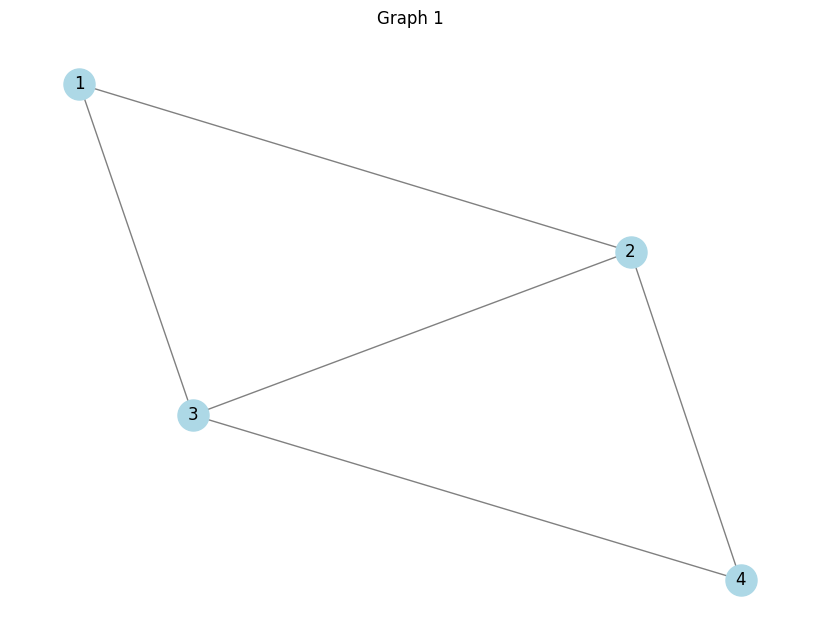

In [10]:
# Создаём неориентированный граф и добавляем узлы и рёбра
graph1 = nx.Graph()
graph1.add_node(1)
graph1.add_nodes_from([2, 3, 4])  # Добавление нескольких узлов

# Добавление рёбер
graph1.add_edge(1, 2)  #по одному
graph1.add_edges_from([(1, 3), (2, 4), (3, 4), (2, 3)]) #по несколько(массивом)

# Визуализируем
draw_graph(graph1, title="Graph 1")


Направленный граф создается с помощью класса `nx.DiGraph`:

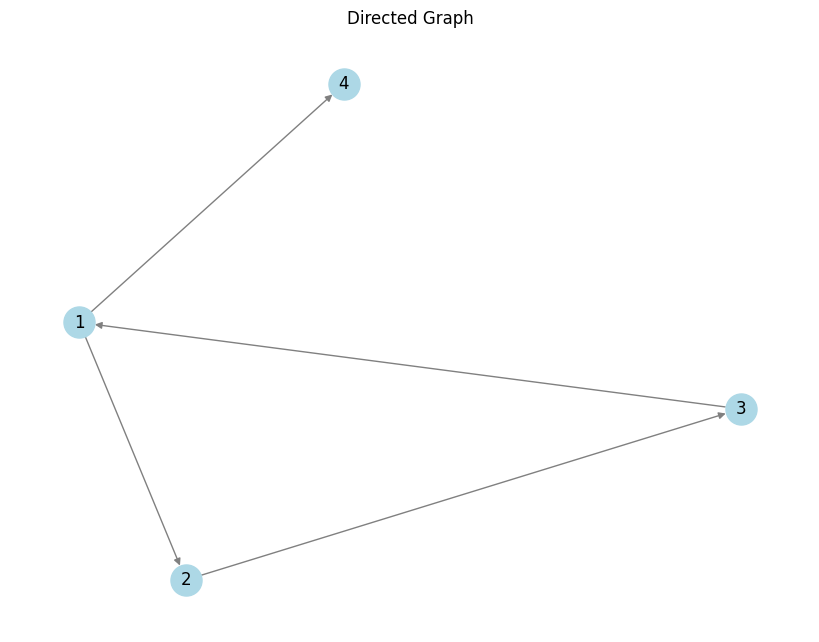

In [11]:
# Направленный граф
directed_graph = nx.DiGraph()
directed_graph.add_edges_from([(1, 2), (2, 3), (3, 1), (1, 4)]) #(от куда, куда)
draw_graph(directed_graph, title="Directed Graph")

Мы также можем создать граф напрямую из списка ребер:

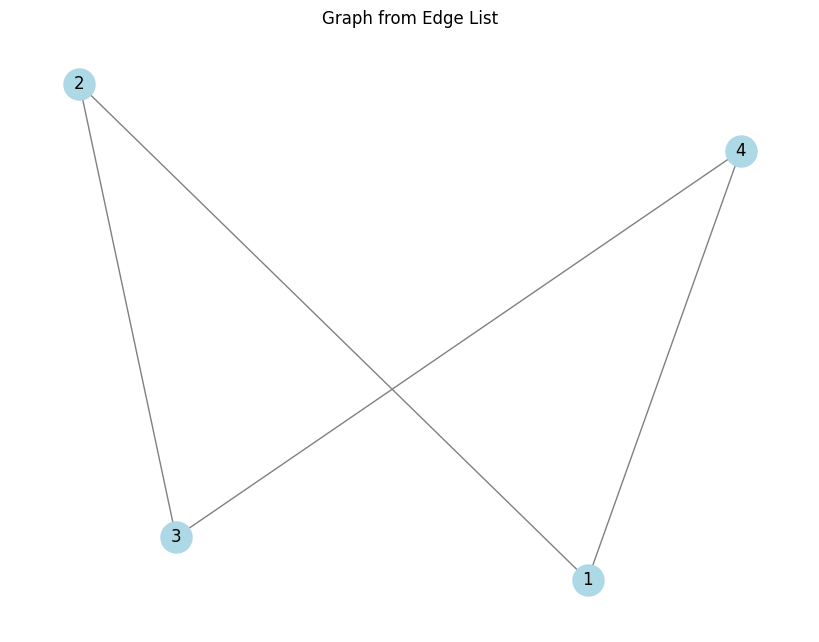

In [12]:
# Список рёбер
edges = [(1, 2), (2, 3), (3, 4), (4, 1)]

# Создаём граф напрямую из списка рёбер
G_from_edges = nx.Graph(edges)
draw_graph(G_from_edges, title="Graph from Edge List")

Опционально мы всегда можем сделать граф взвешенным. Для этого в метод `add_edge()` передается ключевое слово `weight`. Тоже можно сделать и используя метод `add_weighted_edges_from()`:

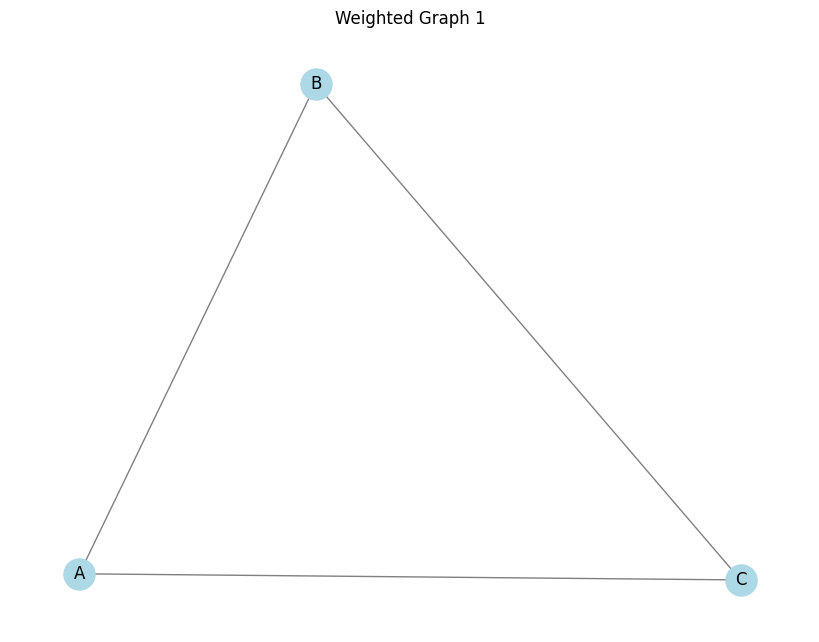

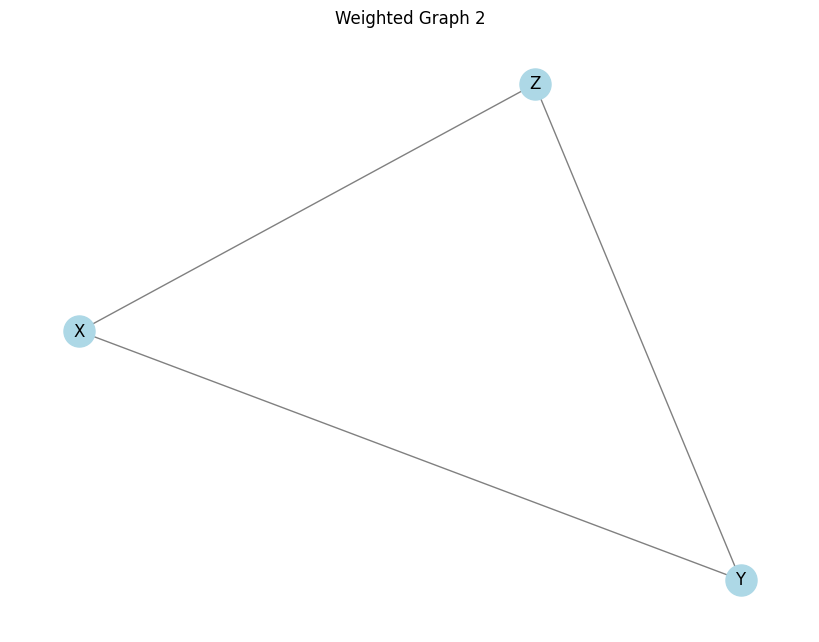

In [13]:
# Взвешенный граф с использованием add_edge()
weighted_graph = nx.Graph()
weighted_graph.add_edge('A', 'B', weight=4.0)
weighted_graph.add_edge('B', 'C', weight=2.5)
weighted_graph.add_edge('C', 'A', weight=3.0)

# Или с использованием add_weighted_edges_from()
weighted_edges = [('X', 'Y', 1.5), ('Y', 'Z', 2.0), ('Z', 'X', 3.5)]
weighted_graph2 = nx.Graph()
weighted_graph2.add_weighted_edges_from(weighted_edges)

draw_graph(weighted_graph, title="Weighted Graph 1")
draw_graph(weighted_graph2, title="Weighted Graph 2")


Названия узлов могут быть произвольными hashable. Мы также может добавлять произвольные аттрибуты в узлам и ребрам:

In [14]:
# Граф с атрибутами
attributed_graph = nx.Graph()
attributed_graph.add_node('Alice', age=25, city='Moscow')
attributed_graph.add_node('Bob', age=30, city='SPb')
attributed_graph.add_node('Charlie', age=35, city='Kazan')

attributed_graph.add_edge('Alice', 'Bob', relationship='friend', years=5)
attributed_graph.add_edge('Bob', 'Charlie', relationship='colleague', years=2)

print("Атрибуты узла Alice:", attributed_graph.nodes['Alice'])
print("Атрибуты ребра Alice-Bob:", attributed_graph['Alice']['Bob'])


Атрибуты узла Alice: {'age': 25, 'city': 'Moscow'}
Атрибуты ребра Alice-Bob: {'relationship': 'friend', 'years': 5}


## Доступ к узлам и ребрам

Networkx предоставляет удобный интерфейс для доступа к узлам/ребрам и их аттрибутам, а также позволяет легко итерироваться по ним. Рассмотрим несколько популярных операций

Количество узлов в графе:

In [16]:
print(f"Количество узлов: {G.number_of_nodes()}")  # или G.order()

Количество узлов: 0


Количество ребер в графе:

In [17]:
print(f"Количество рёбер: {G.number_of_edges()}")

Количество рёбер: 0


Проверка, присутствует ли узел в графе:

In [18]:
print(f"Узел 3 присутствует: {3 in G}")

Узел 3 присутствует: False


Проверка, присутствует ли ребро в графе:

In [19]:
print(f"Ребро (0, 1) присутствует: {(0, 1) in G.edges()}")

Ребро (0, 1) присутствует: False


Итерация по узлам:

In [20]:
print("Узлы:", list(G.nodes()))

Узлы: []


Итерация по ребрам:

In [21]:
print("Рёбра:", list(G.edges()))

Рёбра: []


Итерацией по ребрам вместе с аттрибутами:

In [22]:
print("Рёбра с атрибутами:", list(G.edges(data=True)))

Рёбра с атрибутами: []


## Доступ к соседям

Для начала рассмотрим случай ненаправленного графа.

Множество соседей данного узла можно получить, используя `G.neighbors(n)` или `G.adj[n]`. Например, итерация по соседям узла может выглядеть так:

In [25]:
undirected_G = nx.Graph([(1, 2), (1, 3), (2, 4), (3, 4)])
list(undirected_G.neighbors(1))  #Соседи узла 1 (через neighbors)

[2, 3]

Или так:

In [26]:
list(undirected_G.adj[1])  #Соседи узла 1 (через adj)

[2, 3]

В направленных графах при рассмотрении соседей данного узла, то есть смежных узлов, нам важно разделять in-edges и out-edges. Для получения доступа к in-edges используется метод `G.predecessors()`, а для out-edges метод `G.successors()`.

In [31]:
directed_G = nx.DiGraph([(1, 2), (2, 3), (3, 1), (1, 4)])
print("Предшественники узла 1:", list(directed_G.predecessors(1)))  # in-edges
print("Последователи узла 1:", list(directed_G.successors(1))) # out-edges

Предшественники узла 1: [3]
Последователи узла 1: [2, 4]


Для нахождения степени вершины используется метод `G.degree(n)`, который реализован и для ненаправленных и для направленных графов. Для направленных графов существуют также отдельные методы для полустепеней захода и исхода (indegree и outdegree), `G.in_degree(n)` и `G.out_degree(n)` соответственно.

In [32]:
G = nx.path_graph(4)  # Граф-путь с 4 узлами

for node in G.nodes():
    print(f"Степень узла {node}: {G.degree(node)}")

# Для направленных графов
DG = nx.DiGraph([(1, 2), (2, 3), (3, 1)])
for node in DG.nodes():
    print(f"Полустепень захода узла {node}: {DG.in_degree(node)}")
    print(f"Полустепень исхода узла {node}: {DG.out_degree(node)}")


Степень узла 0: 1
Степень узла 1: 2
Степень узла 2: 2
Степень узла 3: 1
Полустепень захода узла 1: 1
Полустепень исхода узла 1: 1
Полустепень захода узла 2: 1
Полустепень исхода узла 2: 1
Полустепень захода узла 3: 1
Полустепень исхода узла 3: 1


### Упражнение 1

Напишите функцию, вычисляющую среднюю степень соседей для каждого из узлов, у которых в принципе есть соседи

In [36]:
def average_neighbor_degree(G):
    result = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if neighbors: 
            neighbor_degrees = [G.degree(n) for n in neighbors]
            avg_degree = sum(neighbor_degrees) / len(neighbor_degrees)
            result[node] = avg_degree
    return result

G = nx.Graph([(1, 2), (1, 3), (2, 4), (3, 4), (4, 5)])
avg_degrees = average_neighbor_degree(G)
print(avg_degrees)
for node, avg in avg_degrees.items():
    print(f"Средняя степень соседей узла {node}: {avg:.2f}")


{1: 2.0, 2: 2.5, 3: 2.5, 4: 1.6666666666666667, 5: 3.0}
Средняя степень соседей узла 1: 2.00
Средняя степень соседей узла 2: 2.50
Средняя степень соседей узла 3: 2.50
Средняя степень соседей узла 4: 1.67
Средняя степень соседей узла 5: 3.00


## Загрузка и сохранение графов

Наконец, мы можем сохранять графы в файлы и вычитывать их из них. Для простых задач мы можем использовать `adjlist` и `edgelist` форматы:
* `adjlist` является компактным представлением матрицы смежности. Он не подходит для графов с аттрибутами
* `edgelist` является списком ребер с их аттрибутами
* Для обоих методов названия узлов не должны включать пробелов

Методы `nx.read_adjlist()` и `nx.read_edgelist()` используются для чтения графов из файлов соответствующих форматов:

### Упражнение 2

Для n = 10, 20 и 30 найдите соответствующие значения p, при которых почти наверняка пройзодет невзвешенная перколяция в графе Эрдеша-Реньи G(n, p).